Data Shape: (1338, 7)

First 5 rows of the data:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Missing Values:
age         0
sex 

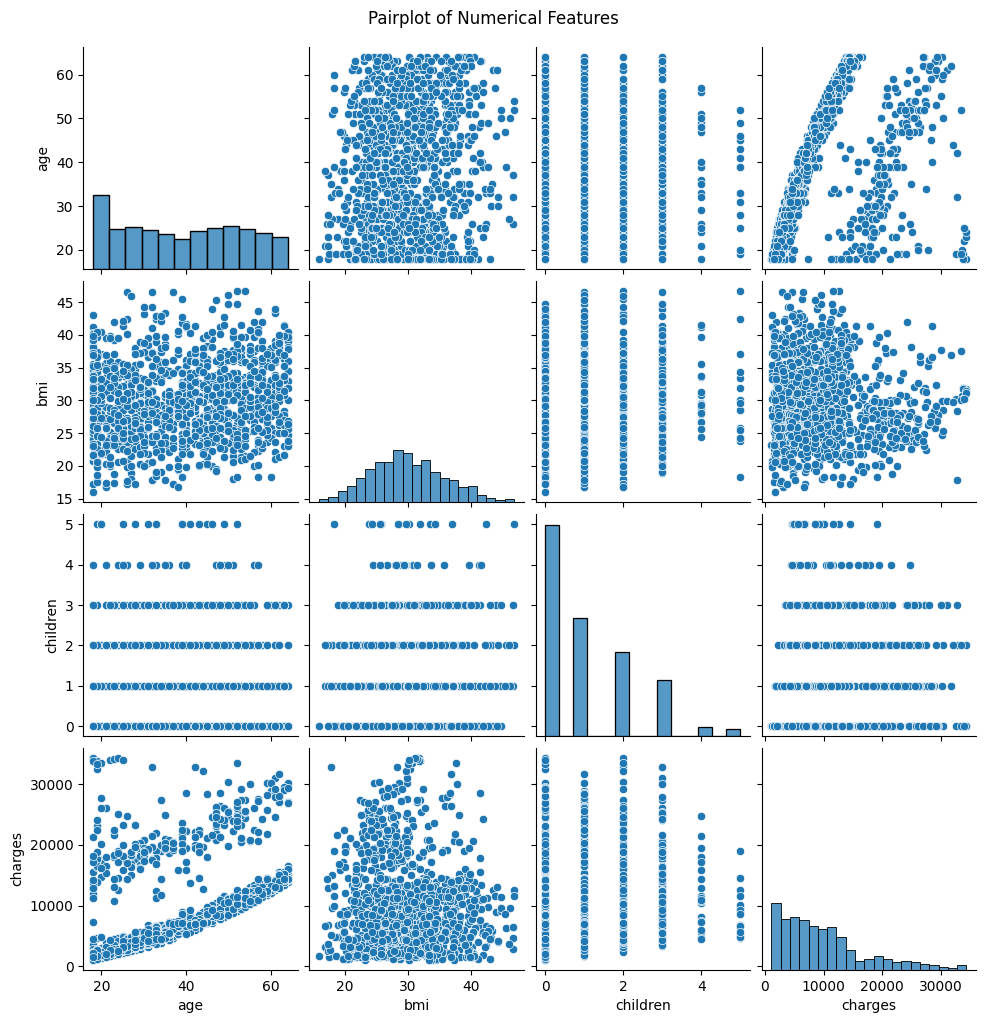

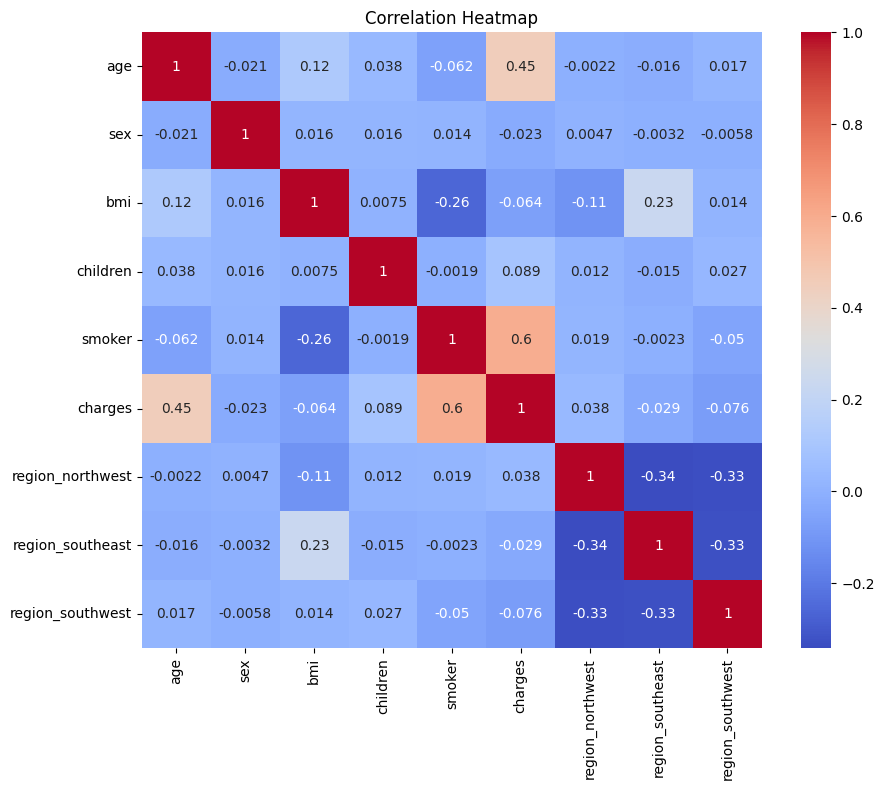

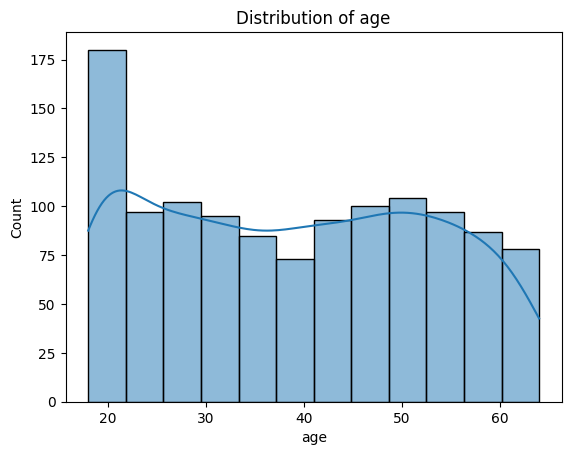

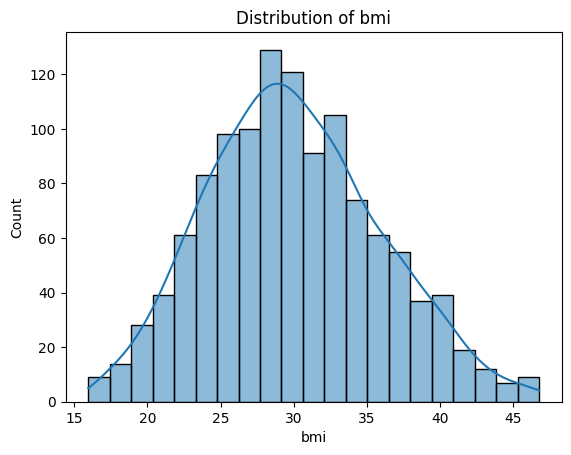

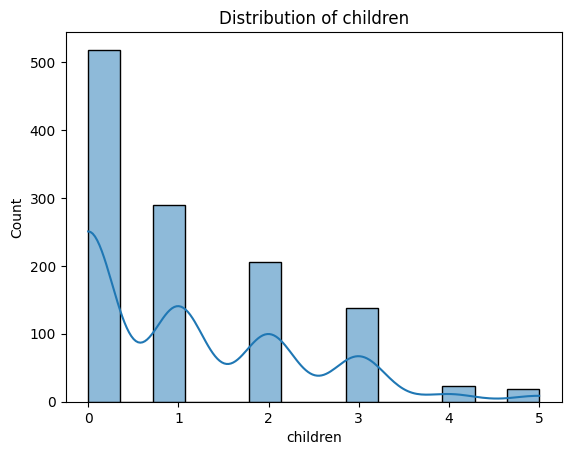

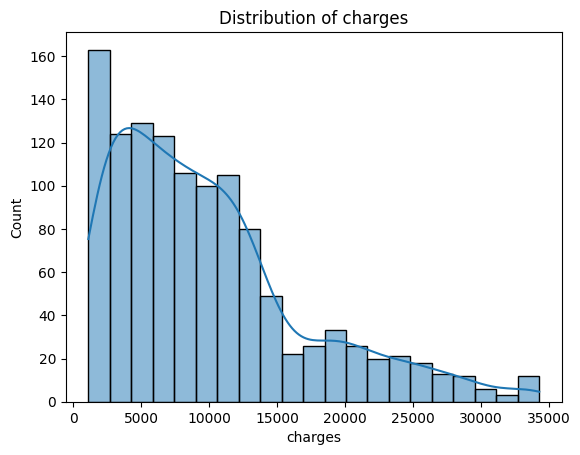

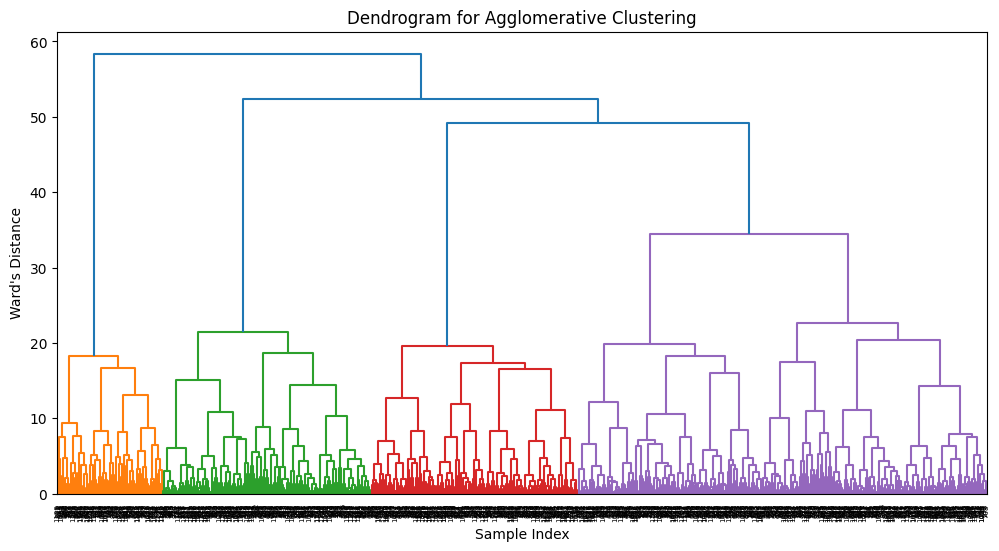

TypeError: AgglomerativeClustering.__init__() got an unexpected keyword argument 'affinity'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy import stats
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Data Loading and Initial Exploration
data = pd.read_csv('insurance MLCRR.csv')
print("Data Shape:", data.shape)
print("\nFirst 5 rows of the data:")
print(data.head())
print("\nData Info:")
data.info()
print("\nMissing Values:")
print(data.isnull().sum())
print("\nDescriptive Statistics:")
print(data.describe())

# 2. Data Preprocessing
## a. Handling Outliers (using IQR)
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

numerical_cols = ['age', 'bmi', 'children', 'charges']
data = remove_outliers(data, numerical_cols)
print("\nData shape after outlier removal:", data.shape)

## b. Encoding Categorical Variables
### Using Label Encoding:
le = LabelEncoder()
data['sex'] = le.fit_transform(data['sex']) # female=0, male=1
data['smoker'] = le.fit_transform(data['smoker']) # no=0, yes=1

### One-Hot Encoding 'region':
data = pd.get_dummies(data, columns=['region'], drop_first=True) # To avoid dummy variable trap

print("\nData after encoding:")
print(data.head())

## c. Scaling Numerical Features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_df = pd.DataFrame(scaled_data, columns=data.columns)

print("\nScaled Data:")
print(scaled_df.head())

# 3. Exploratory Data Analysis (EDA)
## a. Pairplots for Numerical Features
sns.pairplot(data[['age', 'bmi', 'children', 'charges']])
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

## b. Correlation Heatmap
correlation_matrix = data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## c. Distribution Plots
for col in numerical_cols:
    plt.figure()
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# 4. Agglomerative Clustering
## a. Determining the number of clusters (using Dendrogram)
linked = linkage(scaled_df, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, orientation='top',
            labels=None,  # no labels
            distance_sort='ascending',
            show_leaf_counts=True)
plt.title('Dendrogram for Agglomerative Clustering')
plt.xlabel('Sample Index')
plt.ylabel('Ward\'s Distance')
plt.show()

## b. Applying Agglomerative Clustering
n_clusters = 3  # Chosen from dendrogram
cluster = AgglomerativeClustering(n_clusters=n_clusters, affinity='euclidean', linkage='ward')
data['cluster'] = cluster.fit_predict(scaled_df)

print("\nCluster Assignments:")
print(data['cluster'].value_counts())

# 5. Cluster Analysis
## a. Mean values by cluster
cluster_summary = data.groupby('cluster').mean()
print("\nCluster Summary:")
print(cluster_summary)

## b. Visualizing Clusters (example with 'bmi' and 'charges')
plt.figure(figsize=(8, 6))
sns.scatterplot(x='bmi', y='charges', hue='cluster', data=data, palette='viridis')
plt.title('Clusters based on BMI and Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()
